# Neural Machine Translation from English to French

## Register Number: 23BAI1589 (Yashvanth Karunakaran)

### AIM:
To build an NMT system using a Bidirectional GRU encoder and GRU decoder with Bahdanau attention trained on the Tatoeba sentence pairs dataset. Target: BLEU ≥ 0.25 on the test set.

## 1. Data Preparation

Installs NLTK for later BLEU-score evaluation

In [15]:
!pip install -q nltk

Downloading and extracting the Tatoeba EN–FR dataset

In [16]:
import requests
import zipfile
import io
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

url = "https://www.manythings.org/anki/fra-eng.zip"
data_file = os.path.join(DATA_DIR, "fra.txt")

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

if not os.path.exists(data_file):
    print("Downloading Tatoeba EN-FR dataset...")
    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        raise Exception(f"Download failed with status code {response.status_code}")

    z = zipfile.ZipFile(io.BytesIO(response.content))
    z.extractall(DATA_DIR)
    print("Download complete!")
else:
    print("Dataset already exists.")

raw_pairs = []
with open(data_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            raw_pairs.append((parts[0], parts[1]))

print(f"Total sentence pairs: {len(raw_pairs)}")
print(f"Sample pair: {raw_pairs[0]}")
print(f"Last pair: {raw_pairs[-1]}")

Dataset already exists.
Total sentence pairs: 240521
Sample pair: ('Go.', 'Va !')
Last pair: ('"I went drinking with one of my boyfriend\'s friends, and now he\'s furious at me." "Was this friend a guy or a girl?" "A guy, obviously. Why would I go drinking with his female friends?" "Yeah, you\'re right." "His name is Tom. He\'s really hot, and I really want to go drinking with him again."', "«\xa0Je suis allée boire avec un ami de mon compagnon, et voilà qu'il est furieux contre moi.\xa0» «\xa0Était-ce un gars ou une fille\xa0?\xa0» «\xa0Un gars, bien évidemment. Pourquoi irais-je boire avec ses amies\xa0?\xa0» «\xa0Ouais, ça se comprend.\xa0» «\xa0Il s'appelle Tom. Il est trop canon, et j'ai tellement envie d'aller prendre un verre avec lui à nouveau.\xa0»")


## 2. Preprocessing — Clean, Tokenize, Filter

Cleaning and normalizing sentences, then filters pairs by `MAX_LENGTH`. Text normalization + dataset filtering.

In [18]:
import re
import unicodedata

MAX_LENGTH = 10

def normalize(text: str) -> str:
    text = text.lower().strip()
    text = "".join(
        c for c in unicodedata.normalize("NFD", text)
        if unicodedata.category(c) != "Mn"
    )
    text = re.sub(r"([.!?])", r" \1", text)
    text = re.sub(r"[^a-zA-Z.!?]+", " ", text)
    return text.strip()


cleaned_pairs = []
for en, fr in raw_pairs:
    en_c = normalize(en)
    fr_c = normalize(fr)
    if 0 < len(en_c.split()) <= MAX_LENGTH and 0 < len(fr_c.split()) <= MAX_LENGTH:
        cleaned_pairs.append((en_c, fr_c))

print(f"Pairs: {len(cleaned_pairs):,}")
print(f"Sample: {cleaned_pairs[0]}")

Pairs: 194,013
Sample: ('go .', 'va !')


## 3. Vocabulary — Word-to-Index Mappings with Special Tokens

Building word to index vocabularies (with `<pad>/<unk>/<start>/<end>`) and encoders.

In [ ]:
from collections import Counter

PAD, UNK, START, END = "<pad>", "<unk>", "<start>", "<end>"

def build_vocab(sentences, min_freq=2):
    counts = Counter(w for s in sentences for w in s.split())
    words = [w for w, c in counts.items() if c >= min_freq]
    words = [PAD, UNK, START, END] + sorted(words)
    word2idx = {w: i for i, w in enumerate(words)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word


def encode(sentence, word2idx, max_len):
    unk = word2idx[UNK]
    return [word2idx.get(w, unk) for w in sentence.split()[:max_len]]


en_word2idx, en_idx2word = build_vocab([p[0] for p in cleaned_pairs], min_freq=2)
fr_word2idx, fr_idx2word = build_vocab([p[1] for p in cleaned_pairs], min_freq=2)

en_pad_idx = en_word2idx[PAD]
fr_pad_idx = fr_word2idx[PAD]
fr_start_idx = fr_word2idx[START]
fr_end_idx = fr_word2idx[END]

en_vocab_size = len(en_word2idx)
fr_vocab_size = len(fr_word2idx)

print(f"English vocab size: {en_vocab_size}")
print(f"French  vocab size: {fr_vocab_size}")

English vocab size: 9932
French  vocab size: 14837


## 4. Dataset & DataLoader — Encode, Pad, Split

Creating tensors, pads sequences, splits data, and builds PyTorch DataLoaders.

In [ ]:
import random
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

BATCH_SIZE = 64

def make_example(src_text, tgt_text):
    src_ids = encode(src_text, en_word2idx, MAX_LENGTH)
    tgt_ids = [fr_start_idx] + encode(tgt_text, fr_word2idx, MAX_LENGTH - 2) + [fr_end_idx]
    return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = pad_sequence(src_batch, batch_first=True, padding_value=en_pad_idx)
    tgt_pad = pad_sequence(tgt_batch, batch_first=True, padding_value=fr_pad_idx)
    return src_pad, tgt_pad

random.seed(42)
random.shuffle(cleaned_pairs)

n = len(cleaned_pairs)
train_pairs = cleaned_pairs[: int(0.8 * n)]
val_pairs = cleaned_pairs[int(0.8 * n) : int(0.9 * n)]
test_pairs = cleaned_pairs[int(0.9 * n) :]

train_data = [make_example(en, fr) for en, fr in train_pairs]
val_data = [make_example(en, fr) for en, fr in val_pairs]
test_data = [make_example(en, fr) for en, fr in test_pairs]

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

src, tgt = next(iter(train_loader))
print(f"Train: {len(train_data):,}\nVal: {len(val_data):,}\nTest: {len(test_data):,}")
print("Source batch:", tuple(src.shape), "Target batch:", tuple(tgt.shape))

Train: 155,210
Val: 19,401
Test: 19,402
Source batch: (64, 10) Target batch: (64, 10)


## 5. Encoder — Bidirectional GRU (128D Embedding, 256 Units)

Defining the Bidirectional GRU encoder and projects its final state for the decoder

In [ ]:
import torch.nn as nn

EMBED_DIM = 128
HIDDEN_DIM = 256
ENC_DIM = HIDDEN_DIM * 2
DROPOUT = 0.3

class Encoder(nn.Module):
    def __init__(self, vocab_size, pad_idx, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        x = self.dropout(self.embedding(src))
        enc_out, h = self.rnn(x)
        h = torch.cat([h[-2], h[-1]], dim=1)
        h = torch.tanh(self.proj(h)).unsqueeze(0)
        return enc_out, h

## 6. Bahdanau (Additive) Attention Mechanism

Implements Bahdanau (additive) attention to compute a context vector from encoder outputs

In [ ]:
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, enc_dim=ENC_DIM):
        super().__init__()
        self.W1 = nn.Linear(enc_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.V = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, dec_h, enc_out):
        energy = torch.tanh(self.W1(enc_out) + self.W2(dec_h).unsqueeze(1))
        scores = self.V(energy).squeeze(-1)
        attn = F.softmax(scores, dim=1)
        ctx = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)
        return ctx, attn

## 7. Decoder — GRU (256 units) with Attention + Dense Softmax

Defining the GRU decoder with attention and a final softmax classifier over the target vocab. Attention-based autoregressive decoding.

In [26]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, pad_idx, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, enc_dim=ENC_DIM, dropout=DROPOUT):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.attn = BahdanauAttention(hidden_dim, enc_dim)
        self.rnn = nn.GRU(embed_dim + enc_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim + enc_dim + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, hidden, enc_out):
        emb = self.dropout(self.embedding(token.unsqueeze(1)))
        ctx, attn = self.attn(hidden.squeeze(0), enc_out)
        rnn_in = torch.cat([emb, ctx.unsqueeze(1)], dim=2)
        out, hidden = self.rnn(rnn_in, hidden)
        logits = self.fc(torch.cat([out.squeeze(1), ctx, emb.squeeze(1)], dim=1))
        return logits, hidden, attn

## 8. Seq2Seq Model — Encoder + Decoder with Teacher Forcing

Wraps encoder+decoder into a Seq2Seq model and applies teacher forcing during training

In [27]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        bsz, tgt_len = tgt.size()
        out = torch.zeros(bsz, tgt_len, self.decoder.vocab_size, device=self.device)
        enc_out, hidden = self.encoder(src)
        token = tgt[:, 0]
        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(token, hidden, enc_out)
            out[:, t] = logits
            use_tf = random.random() < teacher_forcing_ratio
            token = tgt[:, t] if use_tf else logits.argmax(dim=1)
        return out

## 9. Training — Adam, Masked Loss, Early Stopping

Trains the RNN seq2seq model with masked loss, gradient clipping, and early stopping (saving the best checkpoint).Masked loss means computing loss only on certain elements of your output, while ignoring padding. Gradient clipping limits gradient magnitude before updating weights

In [29]:
import time

LEARNING_RATE = 0.001
N_EPOCHS = 20
GRAD_CLIP = 1.0
PATIENCE = 3
TEACHER_FORCING = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = Encoder(en_vocab_size, en_pad_idx).to(device)
decoder = Decoder(fr_vocab_size, fr_pad_idx).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=fr_pad_idx)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

rnn_train_losses, rnn_val_losses = [], []


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(src, tgt, teacher_forcing_ratio=TEACHER_FORCING if train else 0.0)
            logits = logits[:, 1:].reshape(-1, logits.size(-1))
            gold = tgt[:, 1:].reshape(-1)
            loss = criterion(logits, gold)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total += loss.item()
    return total / len(loader)


best_val = float("inf")
wait = 0
for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, True)
    vl = run_epoch(val_loader, False)
    rnn_train_losses.append(tr)
    rnn_val_losses.append(vl)
    tag = ""
    if vl < best_val:
        best_val = vl
        wait = 0
        torch.save(model.state_dict(), "nmt_best_model.pt")
        tag = "saved"
    else:
        wait += 1
        tag = f" (wait {wait}/{PATIENCE})"
    print(f"Epoch {epoch:02d} | {time.time()-t0:.0f}s | train {tr:.4f} | val {vl:.4f} {tag}")
    if wait >= PATIENCE:
        print("Early stopping.")
        break

model.load_state_dict(torch.load("nmt_best_model.pt", map_location=device))

Device: cuda
Trainable parameters: 18,089,973
Epoch 01 | 148s | train 2.7532 | val 2.3466 saved
Epoch 02 | 150s | train 1.7940 | val 2.1727 saved
Epoch 03 | 150s | train 1.5269 | val 2.1157 saved
Epoch 04 | 151s | train 1.3820 | val 2.1406  (wait 1/3)
Epoch 05 | 150s | train 1.3035 | val 2.1059 saved
Epoch 06 | 164s | train 1.2361 | val 2.0995 saved
Epoch 07 | 146s | train 1.1921 | val 2.1113  (wait 1/3)
Epoch 08 | 145s | train 1.1489 | val 2.1208  (wait 2/3)
Epoch 09 | 150s | train 1.1181 | val 2.1345  (wait 3/3)
Early stopping.


<All keys matched successfully>

## 10. Inference — Greedy Decoding

Translates sentences using greedy decoding (pick best token each step). Autoregressive inference.

In [31]:
def ids_to_text(ids):
    words = []
    for i in ids:
        w = fr_idx2word.get(i, UNK)
        if w == END:
            break
        if w not in (START, PAD):
            words.append(w)
    return " ".join(words)


def encode_src(sentence: str):
    s = normalize(sentence)
    ids = encode(s, en_word2idx, MAX_LENGTH)
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    return x, s.split()


def translate_greedy(sentence: str, max_len=MAX_LENGTH):
    model.eval()
    with torch.no_grad():
        src, src_words = encode_src(sentence)
        enc_out, hidden = model.encoder(src)
        tok = torch.tensor([fr_start_idx], device=device)
        out_ids = []
        attn_rows = []
        for _ in range(max_len):
            logits, hidden, attn = model.decoder(tok, hidden, enc_out)
            tok = logits.argmax(dim=1)
            out_ids.append(tok.item())
            attn_rows.append(attn.squeeze(0).detach().cpu().numpy())
            if tok.item() == fr_end_idx:
                break
    return ids_to_text(out_ids), src_words, attn_rows


for s in ["i am a student .", "he is my friend .", "she loves music ."]:
    fr, _, _ = translate_greedy(s)
    print(f"EN: {s} FR: {fr}")

EN: i am a student . FR: je suis etudiant etudiant .
EN: he is my friend . FR: il est mon ami mon ami .
EN: she loves music . FR: elle aime la musique musique .


## 11. Inference — Beam Search (width=5)

Implements beam search to keep the top-$k$ translation hypotheses. Search-based decoding + (simple) length normalization.

In [33]:
def translate_beam(sentence: str, beam_width=5, max_len=MAX_LENGTH):
    model.eval()
    with torch.no_grad():
        src, _ = encode_src(sentence)
        enc_out, hidden = model.encoder(src)
        beams = [(0.0, [fr_start_idx], hidden, False)]
        completed = []
        for _ in range(max_len):
            candidates = []
            for score, toks, h, done in beams:
                if done:
                    completed.append((score, toks, h, done))
                    continue
                last = torch.tensor([toks[-1]], device=device)
                logits, new_h, _ = model.decoder(last, h, enc_out)
                logp = F.log_softmax(logits, dim=1)
                topk_p, topk_i = logp.topk(beam_width)
                for k in range(beam_width):
                    tok = topk_i[0, k].item()
                    candidates.append((
                        score - topk_p[0, k].item(),
                        toks + [tok],
                        new_h,
                        tok == fr_end_idx,
                    ))
            if not candidates:
                break
            candidates.sort(key=lambda x: x[0])
            beams = candidates[:beam_width]
            if all(b[3] for b in beams):
                completed.extend(beams)
                break
        completed.extend(b for b in beams if not b[3])
        best = min(completed, key=lambda x: x[0] / max(len(x[1]) - 1, 1))
        return ids_to_text(best[1])


for s in ["i am a student .", "he is my friend .", "she loves music ."]:
    g, _, _ = translate_greedy(s)
    b = translate_beam(s, beam_width=5)
    print(f"EN: {s}")
    print(f"greedy: {g}")
    print(f"beam: {b}\n")

EN: i am a student .
greedy: je suis etudiant etudiant .
beam: je suis etudiant etudiant .

EN: he is my friend .
greedy: il est mon ami mon ami .
beam: il est mon ami mon ami .

EN: she loves music .
greedy: elle aime la musique musique .
beam: elle aime la musique douce .



## 12. Evaluation — BLEU Score

Computes corpus BLEU (Bilingual Evaluation Understudy) on test pairs (with smoothing) for greedy vs beam outputs.MT evaluation metric (BLEU).

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def compute_bleu(pairs, use_beam=False):
    refs, hyps = [], []
    for i, (src, ref) in enumerate(pairs, 1):
        hyp = translate_beam(src) if use_beam else translate_greedy(src)[0]
        refs.append([ref.split()])
        hyps.append(hyp.split())
    return corpus_bleu(refs, hyps, smoothing_function=smooth)

greedy_bleu = compute_bleu(test_pairs[:5000], use_beam=False)
print(f"Greedy BLEU: {greedy_bleu:.4f}\n")

beam_bleu = compute_bleu(test_pairs[:5000], use_beam=True)
print(f"Beam BLEU: {beam_bleu:.4f}\n")

for i in range(min(10, len(test_pairs))):
    src, ref = test_pairs[i]
    hyp = translate_greedy(src)[0]
    print("Source:", src)
    print("Ref:",ref)
    print("Pred:", hyp)
    print()

Greedy BLEU: 0.3163

Beam BLEU: 0.3248

Source: was the baby crying then ?
Ref: le bebe pleurait il a ce moment la ?
Pred: le bebe bebe bebe bebe bebe alors lors

Source: we re working on it .
Ref: on y travaille .
Pred: nous y travaillons a dessus .

Source: do you still like tom ?
Ref: t es toujours amoureuse de tom ?
Pred: aimez vous toujours comme tom ?

Source: let s stop at the next rest stop .
Ref: faisons une halte a la prochaine aire de repos .
Pred: arretons nous a la prochaine aire aire .

Source: we may as well start at once .
Ref: on pourrait aussi commencer sans attendre .
Pred: nous aussi aussi prevision commencer .

Source: i m still shopping around .
Ref: je fais encore mon marche .
Pred: je suis encore encore courses courses . courses

Source: what is the cat up to ?
Ref: qu est ce que le chat a en tete ?
Pred: comment est ce que le chat manigance ?

Source: i don t think tom can help us .
Ref: je ne pense pas que tom puisse nous aider .
Pred: je ne pense pas pouvoir 

## 13. Attention Visualization — Heatmaps

Visualizes attention as a heatmap to see source to target alignments. Interpretability using attention matrices.

EN: i love you . FR: je t aime .


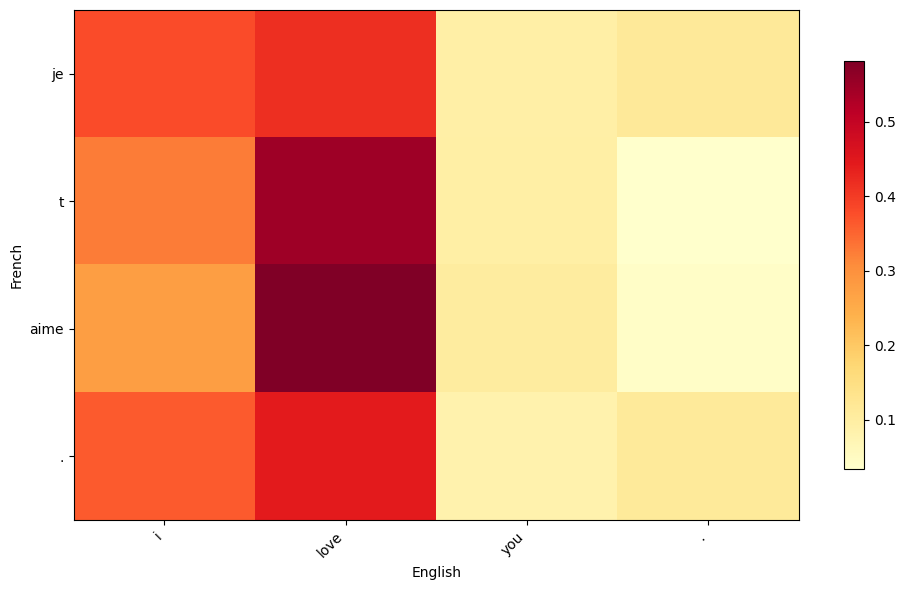

EN: the cat is on the table . FR: le chat est sur la table . table


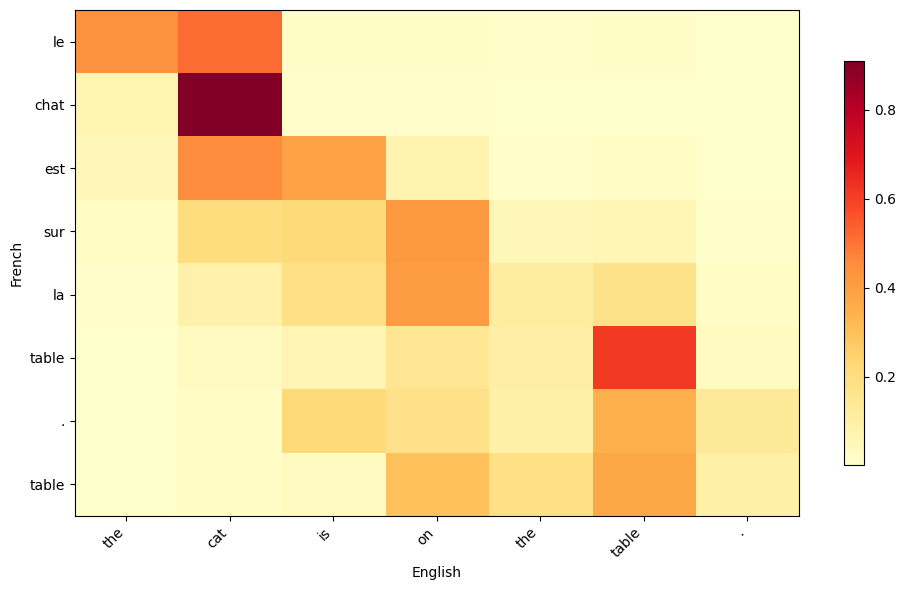

EN: she is very happy . FR: elle est tres heureuse .


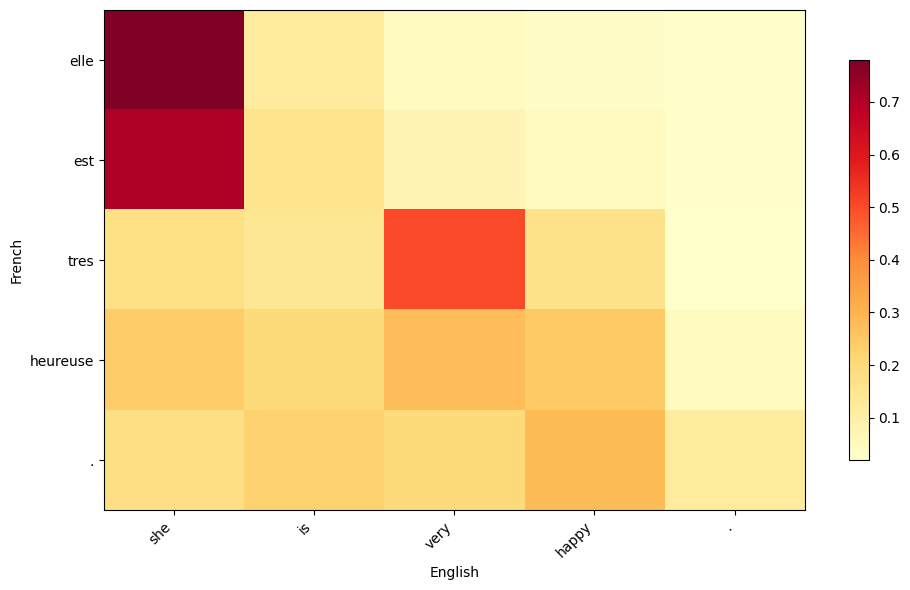

EN: we are going home . FR: nous allons chez nous maison .


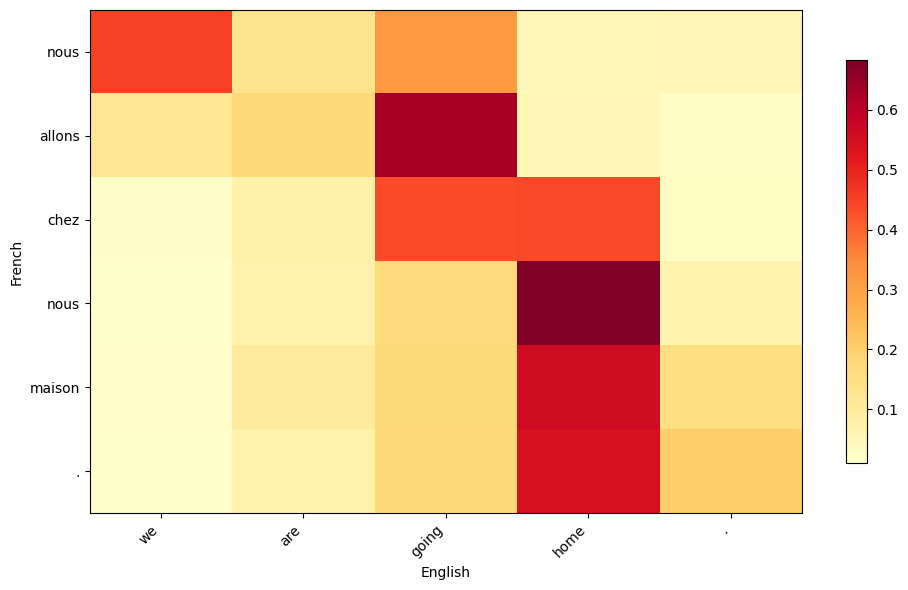

In [38]:
import matplotlib.pyplot as plt
import numpy as np


def plot_attention(src_words, tgt_words, attn_rows, save_path=None):
    attn = np.array(attn_rows)[: len(tgt_words), : len(src_words)]
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(attn, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(src_words)))
    ax.set_yticks(range(len(tgt_words)))
    ax.set_xticklabels(src_words, rotation=45, ha="right")
    ax.set_yticklabels(tgt_words)
    ax.set_xlabel("English")
    ax.set_ylabel("French")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


for s in ["i love you .", "the cat is on the table .", "she is very happy .", "we are going home ."]:
    fr, src_words, attn_rows = translate_greedy(s)
    tgt_words = fr.split()
    if tgt_words and attn_rows:
        print(f"EN: {s} FR: {fr}")
        plot_attention(src_words, tgt_words, attn_rows)

## 14. Learning Curves, Model Summary & Human Evaluation

Plotting training vs validation loss over epochs

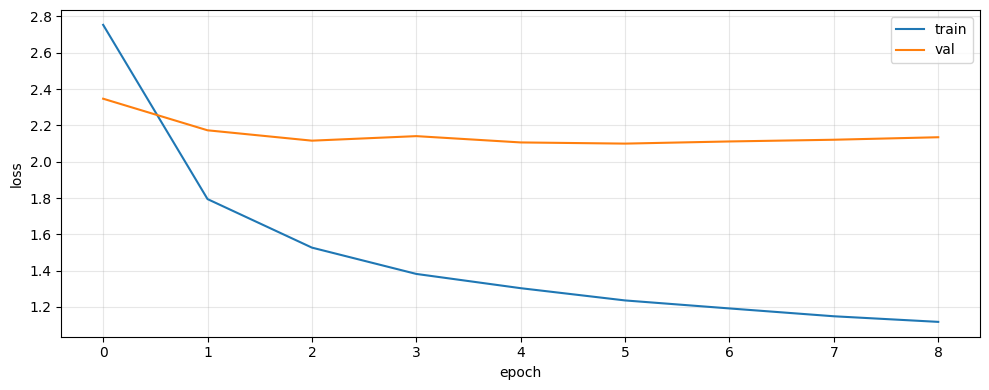

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rnn_train_losses, label="train")
ax.plot(rnn_val_losses, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Printing random test translations (greedy vs beam) for quick qualitative evaluation

In [40]:
random.seed(123)
samples = random.sample(test_pairs, min(10, len(test_pairs)))
for i, (src, ref) in enumerate(samples, 1):
    g = translate_greedy(src)[0]
    b = translate_beam(src)
    print(f"\n{i}.")
    print("src:", src)
    print("ref:", ref)
    print("greedy:", g)
    print("beam:", b)


1.
src: i don t think i can do that .
ref: je ne pense pas que je puisse faire cela .
greedy: je ne pense pas pouvoir faire ca .
beam: je ne pense pas pouvoir faire ca .

2.
src: what s the sign over the door say ?
ref: que dit le panneau sur la porte ?
greedy: comment est la panneau de la porte ?
beam: comment est la panneau de la porte ?

3.
src: is there life on other planets ?
ref: la vie existe t elle sur d autres planetes ?
greedy: y a t il la vie sur l
beam: y a t il la vie sur l

4.
src: don t look down on others .
ref: ne meprise pas les autres .
greedy: ne regardez pas l air sur autres autres
beam: ne regardez pas l air sur autres autres

5.
src: when i m with you i m happy .
ref: lorsque je me trouve avec toi je suis heureux .
greedy: lorsque je suis avec vous je suis heureuse
beam: lorsque je suis avec vous je je suis

6.
src: that makes me nervous .
ref: cela me rend nerveux .
greedy: ca me rend rend nerveux .
beam: ca me rend rend nerveux .

7.
src: i abhor spiders .
ref

# Alternate Approach: Transformer Architecture

Implementation of the same EN to FR translation task using a Transformer model (multi-head self-attention) and compare against the RNN-based model above.

## 15. Transformer — Positional Encoding

Adds sinusoidal positional encoding so a Transformer knows token order. positional encodings for self-attention

In [41]:
import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=MAX_LENGTH + 10, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

## 16. Transformer Model

Defines a Transformer encoder–decoder NMT model. multi-head self-attention for seq2seq

In [ ]:
class TransformerNMT(nn.Module):
    def __init__(self, src_vocab_sz, tgt_vocab_sz, src_pad_idx, tgt_pad_idx, d_model=256, nhead=8, num_layers=3, dim_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab_sz, d_model, padding_idx=src_pad_idx)
        self.tgt_emb = nn.Embedding(tgt_vocab_sz, d_model, padding_idx=tgt_pad_idx)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_LENGTH + 10, dropout=dropout)
        self.tf = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
        )
        self.fc = nn.Linear(d_model, tgt_vocab_sz)

    def _subseq_mask(self, sz):
        return torch.triu(torch.full((sz, sz), float("-inf"), device=next(self.parameters()).device), diagonal=1)

    def forward(self, src, tgt):
        src_pad = src.eq(en_pad_idx)
        tgt_pad = tgt.eq(fr_pad_idx)
        tgt_mask = self._subseq_mask(tgt.size(1))
        src = self.pos_enc(self.src_emb(src) * math.sqrt(self.d_model))
        tgt = self.pos_enc(self.tgt_emb(tgt) * math.sqrt(self.d_model))
        out = self.tf(
            src,
            tgt,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad,
            tgt_key_padding_mask=tgt_pad,
            memory_key_padding_mask=src_pad,
        )
        return self.fc(out)

tf_model = TransformerNMT(en_vocab_size, fr_vocab_size, en_pad_idx, fr_pad_idx).to(device)
tf_params = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(f"Transformer params: {tf_params:,}")

Transformer params: 14,108,661


## 17. Transformer Training

Trains the Transformer with shifted targets (teacher forcing) and early stopping. cross-entropy training for Transformer seq2seq.

In [43]:
TF_EPOCHS = 15
TF_LR = 0.0005
TF_PATIENCE = 3

tf_optimizer = torch.optim.Adam(tf_model.parameters(), lr=TF_LR, betas=(0.9, 0.98), eps=1e-9)
tf_criterion = nn.CrossEntropyLoss(ignore_index=fr_pad_idx)

tf_train_losses, tf_val_losses = [], []

def tf_run_epoch(loader, train: bool):
    tf_model.train() if train else tf_model.eval()
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            if train:
                tf_optimizer.zero_grad()
            logits = tf_model(src, tgt_in)
            loss = tf_criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(tf_model.parameters(), 1.0)
                tf_optimizer.step()
            total += loss.item()
    return total / len(loader)


best_val, wait = float("inf"), 0
for ep in range(1, TF_EPOCHS + 1):
    t0 = time.time()
    tr = tf_run_epoch(train_loader, True)
    vl = tf_run_epoch(val_loader, False)
    tf_train_losses.append(tr)
    tf_val_losses.append(vl)
    tag = ""
    if vl < best_val:
        best_val, wait = vl, 0
        torch.save(tf_model.state_dict(), "tf_nmt_best.pt")
        tag = "saved"
    else:
        wait += 1
        tag = f" (wait {wait}/{TF_PATIENCE})"
    print(f"TF Epoch {ep:02d} | {time.time()-t0:.0f}s | train {tr:.4f} | val {vl:.4f} {tag}")
    if wait >= TF_PATIENCE:
        print("TF early stopping.")
        break

tf_model.load_state_dict(torch.load("tf_nmt_best.pt", map_location=device))

/media/yashix/New Volume/Speech/Lab/.venv/lib/python3.13/site-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/media/yashix/New Volume/Speech/Lab/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


TF Epoch 01 | 80s | train 3.1008 | val 2.2133 saved
TF Epoch 02 | 83s | train 2.0937 | val 1.7747 saved
TF Epoch 03 | 81s | train 1.7906 | val 1.6015 saved
TF Epoch 04 | 83s | train 1.6357 | val 1.5356 saved
TF Epoch 05 | 84s | train 1.5424 | val 1.4554 saved
TF Epoch 06 | 80s | train 1.4793 | val 1.4020 saved
TF Epoch 07 | 77s | train 1.4246 | val 1.3908 saved
TF Epoch 08 | 78s | train 1.3828 | val 1.3618 saved
TF Epoch 09 | 77s | train 1.3478 | val 1.3310 saved
TF Epoch 10 | 80s | train 1.3211 | val 1.3173 saved
TF Epoch 11 | 80s | train 1.2949 | val 1.3189  (wait 1/3)
TF Epoch 12 | 77s | train 1.2773 | val 1.3066 saved
TF Epoch 13 | 77s | train 1.2575 | val 1.2893 saved
TF Epoch 14 | 77s | train 1.2423 | val 1.2757 saved
TF Epoch 15 | 82s | train 1.2284 | val 1.2708 saved


<All keys matched successfully>

## 18. Transformer — Greedy & Beam Search Decoding

Performs greedy and beam decoding for the Transformer by iteratively extending the target sequence. Autoregressive decoding for Transformers.

In [44]:
def tf_translate_greedy(sentence: str, max_len=MAX_LENGTH):
    tf_model.eval()
    with torch.no_grad():
        src, _ = encode_src(sentence)
        toks = [fr_start_idx]
        for _ in range(max_len):
            tgt = torch.tensor([toks], dtype=torch.long, device=device)
            logits = tf_model(src, tgt)
            nxt = logits[:, -1, :].argmax(dim=-1).item()
            toks.append(nxt)
            if nxt == fr_end_idx:
                break
    return ids_to_text(toks)


def tf_translate_beam(sentence: str, beam_width=5, max_len=MAX_LENGTH):
    tf_model.eval()
    with torch.no_grad():
        src, _ = encode_src(sentence)
        beams = [(0.0, [fr_start_idx], False)]
        completed = []
        for _ in range(max_len):
            candidates = []
            for score, toks, done in beams:
                if done:
                    completed.append((score, toks, done))
                    continue
                tgt = torch.tensor([toks], dtype=torch.long, device=device)
                logits = tf_model(src, tgt)
                logp = F.log_softmax(logits[:, -1, :], dim=-1)
                topk_p, topk_i = logp.topk(beam_width)
                for k in range(beam_width):
                    tok = topk_i[0, k].item()
                    candidates.append((score - topk_p[0, k].item(), toks + [tok], tok == fr_end_idx))
            if not candidates:
                break
            candidates.sort(key=lambda x: x[0])
            beams = candidates[:beam_width]
            if all(b[2] for b in beams):
                completed.extend(beams)
                break
        completed.extend(b for b in beams if not b[2])
        best = min(completed, key=lambda x: x[0] / max(len(x[1]) - 1, 1))
        return ids_to_text(best[1])


for s in ["i am a student .", "he is my friend .", "she loves music ."]:
    g = tf_translate_greedy(s)
    b = tf_translate_beam(s)
    print(f"EN: {s}")
    print(f"tf greedy: {g}")
    print(f"tf beam: {b}\n")

EN: i am a student .
tf greedy: je suis etudiant .
tf beam: je suis etudiant .

EN: he is my friend .
tf greedy: c est mon ami .
tf beam: c est mon ami .

EN: she loves music .
tf greedy: elle adore la musique .
tf beam: elle adore la musique .



## 19. Transformer — BLEU Evaluation

Evaluates Transformer translations with BLEU (greedy vs beam). metric-based evaluation for model comparison.

In [47]:
def compute_bleu_tf(pairs, use_beam=False, log_every=1000):
    refs, hyps = [], []
    for i, (src, ref) in enumerate(pairs, 1):
        hyp = tf_translate_beam(src) if use_beam else tf_translate_greedy(src)
        refs.append([ref.split()])
        hyps.append(hyp.split())
    return corpus_bleu(refs, hyps, smoothing_function=smooth)

tf_greedy_bleu = compute_bleu_tf(test_pairs[:5000], use_beam=False)
print(f"TF Greedy BLEU: {tf_greedy_bleu:.4f}\n")

tf_beam_bleu = compute_bleu_tf(test_pairs[:5000], use_beam=True)
print(f"TF Beam BLEU: {tf_beam_bleu:.4f}")

TF Greedy BLEU: 0.4054

TF Beam BLEU: 0.4131


## 20. Comparison — RNN vs Transformer

Prints a compact comparison: parameter counts + BLEU for RNN vs Transformer

In [50]:
print("RNN vs Transformer")
print(f"params: rnn={n_params:,} | tf={tf_params:,}")
print(f"greedy BLEU: rnn={greedy_bleu:.4f} | tf={tf_greedy_bleu:.4f}")
print(f"beam BLEU: rnn={beam_bleu:.4f} | tf={tf_beam_bleu:.4f}")

RNN vs Transformer
params: rnn=18,089,973 | tf=14,108,661
greedy BLEU: rnn=0.3163 | tf=0.4054
beam BLEU: rnn=0.3248 | tf=0.4131


Plots RNN vs Transformer learning curves side-by-side

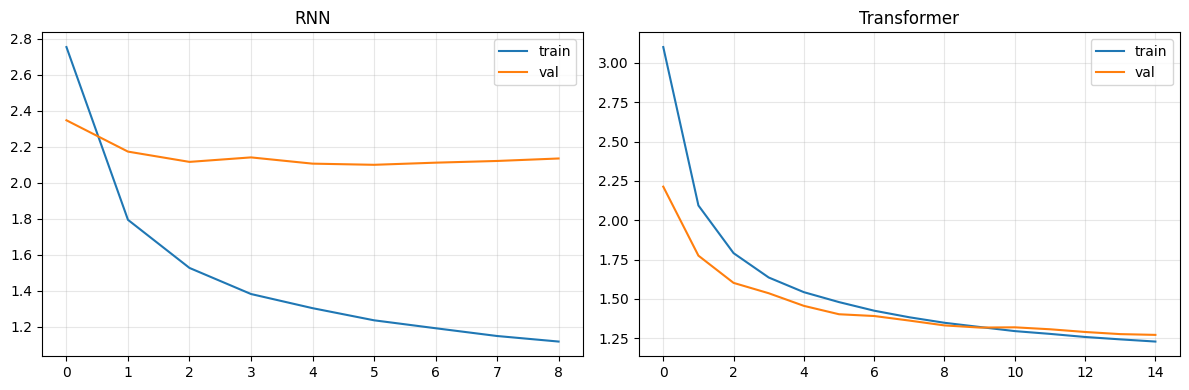

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rnn_train_losses, label="train")
axes[0].plot(rnn_val_losses, label="val")
axes[0].set_title("RNN")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(tf_train_losses, label="train")
axes[1].plot(tf_val_losses, label="val")
axes[1].set_title("Transformer")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Shows sample translations from both models for qualitative comparison

In [52]:
random.seed(456)
samples = random.sample(test_pairs, min(8, len(test_pairs)))
for i, (src, ref) in enumerate(samples, 1):
    rnn_out = translate_greedy(src)[0]
    tf_out = tf_translate_greedy(src)
    print(f"\n{i}.")
    print("src:", src)
    print("ref:", ref)
    print("rnn:", rnn_out)
    print("tf :", tf_out)


1.
src: these ties are very expensive .
ref: ces liens coutent tres cher .
rnn: ces cravates sont tres tres chers .
tf : ces derniers temps sont tres chers .

2.
src: i m trying to get out of here .
ref: j essaye de sortir d ici .
rnn: j essaye de sortir d ici .
tf : j essaye de sortir d ici .

3.
src: have you met the person i hired ?
ref: avez vous rencontre la personne que j ai engagee ?
rnn: avez vous rencontre la personne que j ai
tf : as tu rencontre quelqu un que j ai

4.
src: i got really angry .
ref: je me suis vraiment mise en colere .
rnn: je me suis vraiment mis en en colere
tf : je me suis vraiment mis en colere .

5.
src: my bike has been stolen .
ref: mon velo a ete vole .
rnn: mon velo a ete vole mon velo .
tf : on m a vole mon velo .

6.
src: could you take this please ?
ref: peux tu prendre ca s il te plait ?
rnn: pourrais tu prendre prendre note s il te
tf : pourriez vous prendre ceci s il vous plait

7.
src: they were tired of waiting .
ref: ils en avaient assez d 

### Reference
- [https://www.tensorflow.org/text/tutorials/nmt_with_attention](https://www.tensorflow.org/text/tutorials/nmt_with_attention)
- [https://medium.com/analytics-vidhya/neural-machine-translation-for-hindi-english-sequence-to-sequence-learning-1298655e334a](https://medium.com/analytics-vidhya/neural-machine-translation-for-hindi-english-sequence-to-sequence-learning-1298655e334a)

I didn't use Pre-trained embeddings as mentioned in the Medium blog above but implemented the seq2seq based on above blogs

### Conclusion
#### RNN vs Transformer

parameters:
rnn=18,089,973 | tf=14,108,661

greedy BLEU:
rnn=0.3163 | tf=0.4054

beam BLEU:
rnn=0.3248 | tf=0.4131